In [9]:
import numpy as np
from PIL import Image

(np.array(Image.open('gc_9x9.png').convert('RGB')) / 255 * 100).astype(int).transpose(2, 0, 1)

array([[[  0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0, 100, 100,   0, 100, 100,   0,   0],
        [  0,   0,   0, 100,   0,   0, 100,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0]],

       [[  0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0, 100, 100, 100,   0,   0,   0],
        [  0,   0, 100, 100, 100, 100, 100,   0,   0],
        [  0, 100, 100, 100, 100, 100, 100, 100,   0],
        [  0, 100,   0, 100, 100,   0, 100, 100,   0],
        [  0, 100, 100, 100, 100, 100, 100, 100,   0],
        [  0, 100, 100, 100, 100, 100, 100, 100,   0],
        [  0, 100,   0, 100,   0, 100,   0, 100,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0]],

      

In [1]:
import torch
from torch import nn
from torchvision.transforms.functional import to_tensor, to_pil_image
from pathlib import Path
from PIL import Image, ImageDraw
import numpy as np
from textwrap import indent

In [2]:
def get_conv(t, bias=0., sigmoid=False):
    conv = nn.Conv2d(
        in_channels=t.shape[0],
        out_channels=1,
        kernel_size=t.shape[-2:],
        padding=0,
    )
    conv.bias.data = torch.tensor([float(bias)])
    conv.weight.data = t[None, ...]
    layers = [conv]
    if sigmoid:
        layers.append(nn.Sigmoid())
    return nn.Sequential(*layers)

In [3]:
ims = {
    p.stem: Image.open(p).convert('RGB')
    for p in Path('pacman').glob('*.png')
    if p.stem in ['mr', 'gc']
}
tensors = {
    k: to_tensor(v)
    for k, v in ims.items()
}

In [4]:
biases = {
    'gc': -50,
    'mr': -40,
}

sig_convs = {
    k: get_conv(t, bias=biases[k], sigmoid=True)
    for (k, t) in tensors.items()
}
nosig_convs = {
    k: get_conv(t)
    for k, t in tensors.items()
}

In [5]:
nosig_convs['gc']

Sequential(
  (0): Conv2d(3, 1, kernel_size=(9, 9), stride=(1, 1))
)

In [6]:
with torch.no_grad():
    simmat = {
        k1: {k2: float(conv(tensors[k1]).squeeze()) for k2, conv in nosig_convs.items()}
        for k1 in tensors
    }

In [7]:
import pandas as pd

df = pd.DataFrame(simmat)

In [8]:
df

,gc,mr
gc,84.0,26.0
mr,26.0,52.0


<AxesSubplot:>

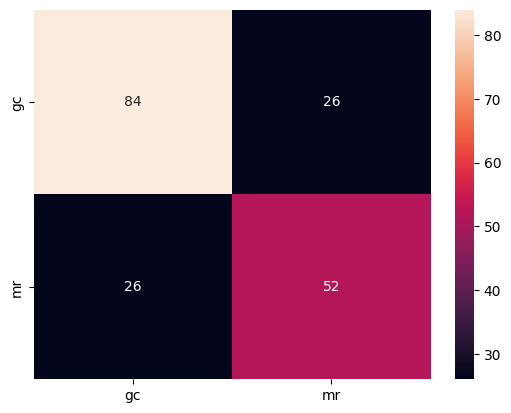

In [9]:
%matplotlib inline
import seaborn as sns

sns.heatmap(df, annot=True, fmt='.4g')

In [10]:
def paste_in_maze(im, maze, x, y):
    new_maze = maze.copy()
    new_maze.paste(im, (x, y))
    return new_maze

to_xy = lambda i, j: [el for el in (j, i)]
maze_population = {
    'gc1': to_xy(25, 115),
    'gc2': to_xy(73, 30),
    'mr': to_xy(57, 60),
    'none': to_xy(5, 45),
    'start': (0, 0),
    'end': (141, 157),
}

def get_populated_maze():
    ar = 496/448
    maze_width = 150
    maze_height = int(maze_width * ar)
    maze = Image.open('maze.png').resize((maze_width, maze_height), 2)
    for k, (x, y) in maze_population.items():
        im_key = k[:2]
        if im_key in ims:
            maze = paste_in_maze(ims[im_key], maze, x, y)
    return maze

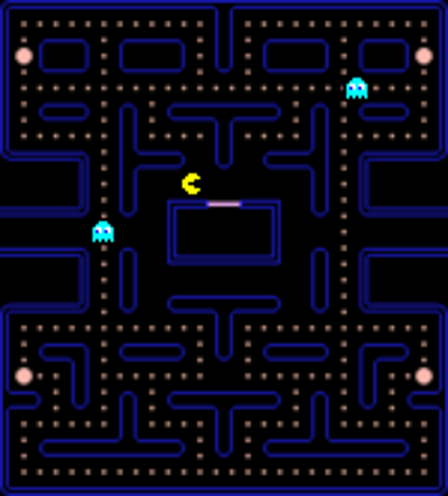

In [11]:
maze_im = get_populated_maze()
maze_t = to_tensor(maze_im)
maze_im_path = Path('../chapters/introduction/image/pacman_kernel/populated_maze.png')
maze_im.save(maze_im_path)
maze_im.resize((448, 496))

In [12]:
with torch.no_grad():
    nosig_outs = {
        k: to_pil_image(conv(maze_t[None, ...]).squeeze())
        for k, conv in nosig_convs.items()
    }
    sig_outs = {
        k: to_pil_image(conv(maze_t[None, ...]).squeeze())
        for k, conv in sig_convs.items()
    }

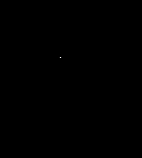

In [13]:
sig_outs['mr']

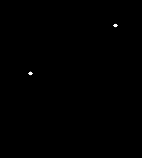

In [14]:
sig_outs['gc']

In [15]:
sig_outs['gc'].size

(142, 158)

# Create TikZ drawings